# Pipeline visualization (post-run)

This notebook **does not** run the CNMF pipeline. Run processing first, for example:

```bash
minian-pipeline -d /path/to/your/folder
```

Then set `DATA_DIR` below to the same folder you passed as `--data` / `-d`.

**On disk**, the CLI writes two Zarr-backed roots under `DATA_DIR`:

- **Intermediate folder** (`minian_intermediate/`) — stepwise arrays such as `varr`, `varr_ref`, `Y_fm_chk`, `Y_hw_chk`, `C_chk`, `A_init`, `C_init`, `sn_spatial`, `YrA`, and others depending on pipeline stage.
- **Merged folder** (`minian/`) — principal outputs (`A`, `C`, `S`, `b`, `f`, `b0`, `c0`, `motion`, `max_proj`, …).

Sections below step through **what lives in those saves** (movies → motion → footprints → traces → summaries). Diagnostics that depended only on **ephemeral notebook state** — e.g. live seed tables before save, intermediate PNR/GMM objects, iterative `A_new` / `C_new` sweeps not written as standalone arrays — cannot be reopened from Zarr and are omitted or abbreviated.

Before loading, the notebook calls `require_existing_dirs` so missing folders fail immediately with an explicit hint.


## Configuration

Set **`DATA_DIR`** to the processed dataset root (`--data` / `-d`). **`output_size`** scales HoloViews/Bokeh render size. **`interactive`**: Panel-backed viewers (`VArrayViewer`, `CNMFViewer`, preprocessing exploration) render only when `interactive=True`; set `interactive=False` for lighter, non-interactive runs.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
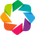

DATA_DIR: /Users/stu_latka/Code/minian/demo_movies
INTPATH: /Users/stu_latka/Code/minian/demo_movies/minian_intermediate
MINIAN_PATH: /Users/stu_latka/Code/minian/demo_movies/minian


In [1]:
%%capture --no-display --no-stdout
%load_ext autoreload
%autoreload 2

import os

import holoviews as hv
import numpy as np
import xarray as xr
from bokeh.io import curdoc
from holoviews.operation.datashader import datashade, regrid
from IPython.display import display
from dask.distributed import Client, LocalCluster

from minian.cnmf import compute_AtC
from minian.constants import get_minian_intermediate_path, minian_folder_under
from minian.preprocessing import denoise, remove_background
from minian.utilities import TaskAnnotation, open_minian, require_existing_dirs
from minian.utilities.logger import configure_logging
from minian.visualization import (
    CNMFViewer,
    VArrayViewer,
    generate_videos,
    visualize_motion,
    visualize_preprocess,
)

hv.notebook_extension("bokeh", width=100)

DATA_DIR = os.path.abspath("../demo_movies")
INTPATH = get_minian_intermediate_path(DATA_DIR)
MINIAN_PATH = minian_folder_under(DATA_DIR)

subset = dict(frame=slice(0, None))
output_size = 100
interactive = True
cmap2use = "Viridis"

for label, p in (
    ("DATA_DIR", DATA_DIR),
    ("INTPATH", INTPATH),
    ("MINIAN_PATH", MINIAN_PATH),
):
    print(f"{label}: {p}")

configure_logging(os.getenv("MINIAN_LOG_LEVEL", "INFO"), force=True)

## Dask (optional)

Starts a **`LocalCluster` + Client** so **`regrid`**, **`datashade`**, and Viewer `.compute()` calls can use multiple processes. Omit this cell **and** the teardown cell at the bottom to stay on Dask’s in-process threaded scheduler only (fewer simultaneous allocations, slower parallelism).


In [2]:
from minian.config import PipelineConfig

_client = globals().get("client")
_cluster = globals().get("cluster")
if _client is not None or _cluster is not None:
    if _client is not None:
        _client.close()
    if _cluster is not None:
        _cluster.close()
    print("Closing previously found cluster")

_viz_cluster_cfg = PipelineConfig(
    intpath=INTPATH,
    dask_chunk_target_mb=100,
)
n_workers = _viz_cluster_cfg.resolved_n_workers()
threads_per_worker = _viz_cluster_cfg.dask_threads_per_worker
worker_memory_limit = _viz_cluster_cfg.dask_worker_memory
chunk_target_mb = _viz_cluster_cfg.dask_chunk_target_mb

cluster = LocalCluster(
    n_workers=n_workers,
    memory_limit=worker_memory_limit,
    resources={"MEM": 1},
    threads_per_worker=threads_per_worker,
    dashboard_address=":8787",
)
annt_plugin = TaskAnnotation()
cluster.scheduler.add_plugin(annt_plugin)
client = Client(cluster)

print(
    f"Started Dask LocalCluster at {cluster.scheduler.address!r}\n"
    f"  n_workers={n_workers}, memory_limit={worker_memory_limit!r}, "
    f"threads_per_worker={threads_per_worker}, chunk_target_mb={chunk_target_mb}\n"
    f"  dashboard {client.dashboard_link!r}"
)

/Users/stu_latka/Code/minian/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 64986 instead
  warnings.warn(


Started Dask LocalCluster at 'tcp://127.0.0.1:64987'
  n_workers=8, memory_limit='2GB', threads_per_worker=2, chunk_target_mb=100
  dashboard 'http://127.0.0.1:64986/status'


## Load saved Minian stores

Verifies folders with **`require_existing_dirs`**, then loads each store with **`open_minian`**: every `*.zarr` subdirectory under the given paths is merged into one `xarray.Dataset`. That matches the on-disk layout produced after saving pipeline intermediates and final merges.


In [3]:
require_existing_dirs(
    {
        "intermediate (intpath)": INTPATH,
        "minian output": MINIAN_PATH,
    },
    hint="Run the pipeline first.",
)

ds_int = open_minian(INTPATH)
ds_out = open_minian(MINIAN_PATH)


def _require(ds: xr.Dataset, name: str) -> xr.DataArray:
    if name not in ds.data_vars:
        raise KeyError(
            f"{name!r} not in dataset; have {sorted(map(str, ds.data_vars))}"
        )
    return ds[name]


def _maybe(ds: xr.Dataset, name: str) -> xr.DataArray | None:
    return ds[name] if name in ds.data_vars else None


varr = _require(ds_int, "varr")
varr_ref = _require(ds_int, "varr_ref")
Y_fm_chk = _require(ds_int, "Y_fm_chk")
motion = _require(ds_out, "motion")
max_proj = _require(ds_out, "max_proj")

A = _require(ds_out, "A")
C = _require(ds_out, "C")
S = _require(ds_out, "S")
C_chk = _require(ds_int, "C_chk")

Y_hw_chk = _maybe(ds_int, "Y_hw_chk")
A_init = _maybe(ds_int, "A_init")
C_init = _maybe(ds_int, "C_init")
sn_spatial = _maybe(ds_int, "sn_spatial")
YrA = _maybe(ds_int, "YrA")

b = _maybe(ds_out, "b")
f = _maybe(ds_out, "f")
b0 = _maybe(ds_out, "b0")
c0 = _maybe(ds_out, "c0")

print("intermediate:", sorted(map(str, ds_int.data_vars)))
print("minian out:  ", sorted(map(str, ds_out.data_vars)))

intermediate: ['A', 'A_init', 'A_mrg', 'A_new', 'C', 'C_chk', 'C_chk_new', 'C_init', 'C_mrg', 'C_mrg_chk', 'C_new', 'S', 'S_new', 'Y_fm_chk', 'Y_hw_chk', 'Yb', 'YrA', 'b', 'b0', 'b0_new', 'c0', 'c0_new', 'f', 'g', 'max_res', 'sig_mrg', 'sn_spatial', 'varr', 'varr_ref']
minian out:   ['A', 'C', 'S', 'b', 'b0', 'c0', 'f', 'max_proj', 'motion']


## Raw movie (`varr`)

Loads the cropped raw movie (`varr` from the intermediate folder). Applies **`hv.output`** for plot sizing; when **`interactive=True`**, **`VArrayViewer`** adds playback, sliders, and simple summary curves.


In [4]:
hv.output(size=output_size)
if interactive:
    display(VArrayViewer(varr, framerate=5, summary=["mean", "max"]).show())

BokehModel(combine_events=True, render_bundle={'docs_json': {'3fd101ae-be92-4944-af4d-9ae216b8219d': {'version…

## Raw vs preprocessed (`varr` / `varr_ref`) — side-by-side layout

Two movies in **`VArrayViewer`** with **`layout=True`**: aligned side-by-side view of **`varr`** (raw crop) versus **`varr_ref`** (after reference preprocessing branch used by the pipeline).


In [5]:
hv.output(size=int(output_size * 0.7))
if interactive:
    display(
        VArrayViewer(
            [varr.rename("original"), varr_ref.rename("glow_removed")],
            framerate=5,
            summary=None,
            layout=True,
        ).show()
    )

BokehModel(combine_events=True, render_bundle={'docs_json': {'95586965-1839-441e-8f77-b3f70657661d': {'version…

## After denoise + background removal (`varr_ref` only)

Movie **`varr_ref`** after preprocessing (denoise / background subtraction on the pipeline’s chosen path). **`interactive=True`** uses **`VArrayViewer`** for scrolling and summaries.


In [6]:
hv.output(size=output_size)
if interactive:
    display(VArrayViewer(varr_ref, framerate=5, summary=["mean", "max"]).show())

BokehModel(combine_events=True, render_bundle={'docs_json': {'3dce0ea4-7774-484e-b721-1ccdf4624cdb': {'version…

## Preprocess parameter exploration (`visualize_preprocess`)

On **one reference frame** from **`varr_ref`**, **`visualize_preprocess`** builds small HoloMaps that sweep preprocessing knobs — first **median** denoise (**`ksize`** grid), then **tophat** background removal (**`wnd`** grid). This is exploratory (recompute kernels on demand), not “compare two already-saved movies.”


In [7]:
hv.output(size=int(output_size * 0.6))
if interactive:
    display(
        visualize_preprocess(
            varr_ref.isel(frame=0).compute(),
            denoise,
            method=["median"],
            ksize=[5, 7, 9],
        )
    )

BokehModel(combine_events=True, render_bundle={'docs_json': {'7e970d7f-f199-4633-ada8-8e550085b5bb': {'version…

In [8]:
hv.output(size=int(output_size * 0.6))
if interactive:
    display(
        visualize_preprocess(
            varr_ref.isel(frame=0).compute(),
            remove_background,
            method=["tophat"],
            wnd=[10, 15, 20],
        )
    )

BokehModel(combine_events=True, render_bundle={'docs_json': {'e2a2707f-a649-4cd5-a181-d04a222c0383': {'version…

## Motion correction — movies and shifts

**`VArrayViewer`** with labeled streams (`before_mc` / `after_mc`) stacks raw versus motion-corrected footage; **`visualize_motion`** plots estimated shifts from **`motion`** (merged output).


In [9]:
hv.output(size=int(output_size * 0.7))
if interactive:
    display(
        VArrayViewer(
            [varr_ref.rename("before_mc"), Y_fm_chk.rename("after_mc")],
            framerate=5,
            summary=None,
            layout=True,
        ).show()
    )

BokehModel(combine_events=True, render_bundle={'docs_json': {'f71042bd-bb50-4c58-bb3a-ee124239715d': {'version…

In [10]:
hv.output(size=output_size)
visualize_motion(motion)

:NdOverlay   [Element]
   :Curve   [frame]   (motion)

## Max projections: FOV before MC vs height/width–registered FOV

Per-frame tiles of **`Y_hw_chk`** (intermediate motion-corrected movie on **height × width** chunks): **`hv.Image`** with **`regrid`** to keep responsiveness. Confirms warp/FOV after MC.


In [11]:
if Y_hw_chk is None:
    print("Y_hw_chk not in intermediate store — skip max-projection comparison.")
else:
    im_opts = dict(
        frame_width=500,
        aspect=varr_ref.sizes["width"] / varr_ref.sizes["height"],
        cmap=cmap2use,
        colorbar=True,
        show_title=False,
    )
    hv.output(size=output_size)
    display(
        (
            regrid(
                hv.Image(
                    varr_ref.max("frame").compute().astype(np.float32),
                    ["width", "height"],
                    label="before_mc",
                ).opts(**im_opts)
            )
            + regrid(
                hv.Image(
                    Y_hw_chk.max("frame").compute().astype(np.float32),
                    ["width", "height"],
                    label="after_mc",
                ).opts(**im_opts)
            )
        )
    )

BokehModel(combine_events=True, render_bundle={'docs_json': {'8f36cbd1-64fe-4945-9670-d037d3fd8af9': {'version…

## Saved `max_proj` (used for seeding)

Plots the **`max_proj`** array stored with results (projection used during seed-related steps). Scatter overlays and GMM diagnostic plots (**`visualize_seeds`**, **`visualize_gmm_fit`**) need live seed/PNR/GMM structures that **are not** serialized as standalone Zarr in typical headless runs, so those overlays are skipped here unless you recreate those objects elsewhere.


In [12]:
hv.output(size=output_size)
regrid(
    hv.Image(
        max_proj.astype(np.float32),
        kdims=["width", "height"],
        label="max_proj",
    ).opts(
        frame_width=500,
        aspect=int(max_proj.sizes["width"]) / int(max_proj.sizes["height"]),
        cmap=cmap2use,
        colorbar=True,
    )
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'3718f643-60e2-41bf-b142-4df72c310075': {'version…

## Noise estimate (`sn_spatial`)

**`sn_spatial`** from the intermediate folder: spatial map of spectral noise estimates (from the FFT noise pipeline step). Helps judge whether registration / masking left stable variance.


In [13]:
if sn_spatial is None:
    print("sn_spatial not found — skip.")
else:
    hv.output(size=int(output_size * 0.6))
    display(
        regrid(
            hv.Image(
                sn_spatial.astype(np.float32),
                kdims=["width", "height"],
            ).opts(
                frame_width=500,
                aspect=int(sn_spatial.sizes["width"]) / int(sn_spatial.sizes["height"]),
                cmap=cmap2use,
                colorbar=True,
            )
        ).relabel("sn_spatial")
    )

BokehModel(combine_events=True, render_bundle={'docs_json': {'c94af5e1-b335-4b75-b56e-76b3ce8d89f9': {'version…

## Initial `A_init` / `C_init` and final background `b` / `f`

Loads **initialization** footprints **`A_init`** and **`C_init`** from intermediates alongside **merged** spatial/temporal backgrounds **`b`** and **`f`**. That mixes “first CNMF instantiation” spatial/temporal matrices with backgrounds after the alternating updates—a quick check that saved stages line up geometrically before diving into **`A`** / **`C`**.


In [14]:
hv.output(size=int(output_size * 0.55))
if A_init is None or C_init is None:
    print("A_init or C_init missing — skip init footprint panel.")
elif b is None or f is None:
    print("b or f missing on merged dataset — skip background row.")
else:
    im_opts = dict(
        frame_width=500,
        aspect=A_init.sizes["width"] / A_init.sizes["height"],
        cmap=cmap2use,
        colorbar=True,
        show_title=False,
    )
    cr_opts = dict(
        frame_width=750,
        aspect=1.5 * A_init.sizes["width"] / A_init.sizes["height"],
        show_title=False,
    )
    display(
        (
            regrid(
                hv.Image(
                    A_init.max("unit_id").rename("A_init").compute().astype(np.float32),
                    kdims=["width", "height"],
                ).opts(**im_opts)
            ).relabel("Initial spatial (max over units)")
            + regrid(
                hv.Image(
                    C_init.rename("C_init").compute().astype(np.float32),
                    kdims=["frame", "unit_id"],
                ).opts(cmap=cmap2use, colorbar=True, **cr_opts)
            ).relabel("Initial C_init")
            + regrid(
                hv.Image(
                    b.rename("b").compute().astype(np.float32),
                    kdims=["width", "height"],
                ).opts(**im_opts)
            ).relabel("Final background spatial b")
            + datashade(
                hv.Curve(f.rename("f").compute(), kdims=["frame"]), min_alpha=200
            )
            .opts(**cr_opts)
            .relabel("Final background temporal f")
        ).cols(2)
    )

/Users/stu_latka/Code/minian/.venv/lib/python3.12/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


BokehModel(combine_events=True, render_bundle={'docs_json': {'59ef2f88-e161-4ff9-a30a-5daf26877825': {'version…

## Final spatial footprints (max projection + occupancy)

From merged **`A`**: (1) max across **`unit_id`** for a summed-intensity anatomical sketch, (2) per-pixel **occupancy** (count of footprints above threshold). Quickly spots dense overlap or missing patches.


In [15]:
hv.output(size=int(output_size * 0.6))
opts = dict(
    frame_height=int(A.sizes["height"]),
    frame_width=int(A.sizes["width"]),
    colorbar=True,
    cmap="Viridis",
)
display(
    (
        regrid(
            hv.Image(
                A.max("unit_id").compute().astype(np.float32).rename("A"),
                kdims=["width", "height"],
            ).opts(**opts)
        ).relabel("Spatial max over units")
        + regrid(
            hv.Image(
                (A.fillna(0) > 0).sum("unit_id").compute().astype(np.uint8).rename("A"),
                kdims=["width", "height"],
            ).opts(**opts)
        ).relabel("Binary occupancy (sum units)")
    ).cols(2)
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'468e2676-b0f6-4835-89d0-900ed641e743': {'version…

## Final temporal `C` and `S` heatmaps

Merged traces: continuous activity **`C`** and sparse events **`S`**, shown as **`frame × unit_id`** heatmaps. **`regrid`** keeps the raster responsive when many cells are loaded.


In [16]:
hv.output(size=int(output_size * 0.6))
opts_im = dict(frame_width=500, aspect=2, colorbar=True, cmap=cmap2use)
display(
    (
        regrid(
            hv.Image(
                C.compute().astype(np.float32).rename("C"), kdims=["frame", "unit_id"]
            ).opts(**opts_im)
        ).relabel("C")
        + regrid(
            hv.Image(
                S.compute().astype(np.float32).rename("S"), kdims=["frame", "unit_id"]
            ).opts(**opts_im)
        ).relabel("S")
    ).cols(2)
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'20c0bd78-38fa-45de-8882-71d433781b89': {'version…

## Residual traces `YrA` (sample units)

**`YrA`** (residual fluorescence traces per **`unit_id`**) saved on the intermediate path. Below: a handful of **`hv.Curve`** panels versus **`frame`** for quick inspection without running the full interactive temporal-debug layout.


In [17]:
if YrA is None:
    print("YrA not in intermediate store — skip.")
else:
    hv.output(size=int(output_size))
    uids = YrA.coords["unit_id"].values[: min(8, YrA.sizes["unit_id"])]
    curves = hv.Overlay()
    for u in uids:
        curves *= hv.Curve(
            YrA.sel(unit_id=u).compute().astype(np.float32),
            kdims=["frame"],
        ).relabel(str(u))
    display(curves.opts(hv.opts.Curve(width=700, height=200)))

:Overlay
   .Curve.A_0 :Curve   [frame]   (YrA)
   .Curve.A_1 :Curve   [frame]   (YrA)
   .Curve.A_2 :Curve   [frame]   (YrA)
   .Curve.A_3 :Curve   [frame]   (YrA)
   .Curve.A_4 :Curve   [frame]   (YrA)
   .Curve.A_5 :Curve   [frame]   (YrA)
   .Curve.A_6 :Curve   [frame]   (YrA)
   .Curve.A_7 :Curve   [frame]   (YrA)

## Denoised reconstruction heatmap (`compute_AtC`)

Cheap **preview** of the reconstructed movie term **`A × C`** (via **`compute_AtC`**): spatial arrays are cropped/strided before multiply so we never materialize the full **`frame × height × width`** tensor in RAM. Intended as an eyeball check (`frame × height` slab after collapsing **`width`**), not a production export.


In [18]:
hv.output(size=int(output_size * 0.6))
# Full AtC is frame x height x width and can be too large to materialize in-memory.
# Build a lightweight preview by downsampling first, then collapsing one spatial axis.
A_ds = A.isel(height=slice(None, None, 4), width=slice(None, None, 4))
C_ds = C_chk.isel(frame=slice(None, None, 2))
AC_preview = compute_AtC(A_ds, C_ds).mean("width").compute().astype(np.float32)
display(
    regrid(
        hv.Image(
            AC_preview,
            kdims=["frame", "height"],
        ).opts(frame_width=600, aspect=2, cmap="Viridis", colorbar=True)
    ).relabel("AtC preview (downsampled, using C_chk)")
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'c68c0776-7d4c-4d38-8444-75f3ae493d5f': {'version…

## Summary video (`generate_videos`)

Renders **`generate_videos`** on disk under **`DATA_DIR`**: stacks raw subsets, corrected movies, footprints, traces, etc. into a downloadable MP4 (arguments mirror the exporter used after full CNMF saves).


In [19]:
generate_videos(varr.sel(subset), Y_fm_chk, A=A, C=C_chk, vpath=DATA_DIR)

ffmpeg version 8.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.6.4.2)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvmaf --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.100 / 60. 26.100
  libavcodec     62. 28.100 / 62. 28.100
  libavformat    62. 12.100 / 62. 12.100
  libavdevice    62.  3.100 / 62.  3.100
  libavfilter    11. 14.100 / 11. 14.100
  libswscale      9.  5.100 /  9.  5.100
  libswresample   6.  3.100 /  6.  3.100
Input #0, rawvideo, from 'pipe:':
  Duration: N/A, start: 0.000000, bitrate: 288768 kb/s
  Stream #0:0: Video: rawvideo (Y800 / 0x30303859), gray, 1504x960, 288768 kb/s, 25 tbr, 25 tbn
Strea

'/Users/stu_latka/Code/minian/demo_movies/minian.mp4'

## Interactive CNMF explorer (`CNMFViewer`)

**`CNMFViewer`**: Panel + HoloViews UI for paging units, footprints, temporal traces, and overlays on the corrected movie. Use **`interactive=True`**. With an active **`LocalCluster`**, interactive updates can spike RAM; adjust worker limits or skip the cluster cells if stability matters.


In [22]:
if interactive:
    display(CNMFViewer(A=A, C=C, S=S, org=Y_fm_chk).show())

BokehModel(combine_events=True, render_bundle={'docs_json': {'b8500d10-12be-45b3-ae91-673a706774dc': {'version…

## Teardown

Closes **`cluster`** / **`client`** if variables exist after the optional Dask cell. Skip this cell entirely when no cluster was started.


In [21]:
client_ = globals().get("client")
cluster_ = globals().get("cluster")
if client_ is not None:
    client_.close()
if cluster_ is not None:
    cluster_.close()

2026-05-05 14:05:58,962 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/Users/stu_latka/Code/minian/.venv/lib/python3.12/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/stu_latka/Code/minian/.venv/lib/python3.12/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/stu_latka/Code/minian/.venv/lib/python3.12/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/Users/stu_latka/Code/minian/.venv/lib/python3.12/site-packages/dis